[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_06_autoencoders.ipynb)

Starting from this notebook, we will use **PyTorch** as our deep learning framework to build many neural network models.

There are several excellent deep learning libraries (for example **PyTorch**, **TensorFlow**, and **JAX**). In this tutorial, we choose PyTorch because it is widely used in research and industry, has a clean Python-first API, and makes model experimentation very convenient.

### PyTorch overview

PyTorch provides:
- `torch` for tensor operations (similar to NumPy, with CPU/GPU support)
- `torch.nn` for neural network layers and model building
- `torch.optim` for optimization algorithms (SGD, Adam, etc.)
- `torch.utils.data` for datasets and mini-batch data loading

### Core concepts: tensors and automatic differentiation

- **Tensor**: the main data structure in PyTorch (scalar, vector, matrix, or higher-dimensional array).
- **Automatic differentiation (autograd)**: PyTorch tracks operations on tensors and automatically computes gradients via backpropagation, so we can train neural networks efficiently.

Useful references:
- PyTorch main docs: https://pytorch.org/docs/stable/
- PyTorch tutorials: https://pytorch.org/tutorials/
- Tensor basics: https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html
- Automatic differentiation (autograd): https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html

In [2]:
# Imports for Step 6 autoencoder experiments (PyTorch + plotting).
# pip install torch  (if needed — CPU version is fine for this tutorial)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
rng = np.random.default_rng(42)

In [3]:
# =============================================================================
# PART A — Quick PyTorch primer
# =============================================================================
print("=" * 60)
print("  PART A — PyTorch in 2 minutes")
print("=" * 60)

# Tensors — like numpy arrays
x = torch.tensor([1.0, 2.0, 3.0])
print(f"\n  Tensor:          {x}")
print(f"  Shape:           {x.shape}")
print(f"  Sum:             {x.sum().item():.1f}")

# Autograd — automatic differentiation
# This is what makes backpropagation effortless.
w = torch.tensor(2.0, requires_grad=True)   # a single learnable parameter
y = (w - 5.0) ** 2                          # loss = (w-5)²
y.backward()                                 # compute dL/dw
print(f"\n  w = {w.item()}, L = (w-5)² = {y.item()}")
print(f"  dL/dw = 2*(w-5) = {w.grad.item()}  ← PyTorch computed this automatically")
print(f"  (We would update: w ← w - η * dL/dw)")

print("""
  That's it. PyTorch's autograd does this for millions of parameters
  simultaneously via the chain rule (backpropagation).
  We never write gradient formulas by hand.
""")

  PART A — PyTorch in 2 minutes

  Tensor:          tensor([1., 2., 3.])
  Shape:           torch.Size([3])
  Sum:             6.0

  w = 2.0, L = (w-5)² = 9.0
  dL/dw = 2*(w-5) = -6.0  ← PyTorch computed this automatically
  (We would update: w ← w - η * dL/dw)

  That's it. PyTorch's autograd does this for millions of parameters
  simultaneously via the chain rule (backpropagation).
  We never write gradient formulas by hand.



In [4]:
# =============================================================================
# PART B — Simulated physics dataset: GW-inspired event features
# =============================================================================
print("=" * 60)
print("  PART B — Simulated GW event dataset (16 features)")
print("=" * 60)

# Simulate three populations of compact binary mergers:
#   Pop 0: Stellar-origin BBH   (low mass, moderate SNR)
#   Pop 1: High-mass BBH        (high mass, high SNR)
#   Pop 2: BNS                  (very low chirp mass, short duration)
# Each event has 16 features (think: template bank outputs at different masses,
# or time-frequency morphology features).

N_POP   = [400, 250, 150]
N_TOTAL = sum(N_POP)
D_INPUT = 16    # observed feature dimension
D_LATENT = 2    # we want to compress to 2D for visualisation

def make_population(n, center, scale, seed):
    rng_local = np.random.default_rng(seed)
    base = rng_local.normal(center, scale, (n, D_INPUT))
    # Add some non-linear correlations to make it interesting
    base[:, 1] += 0.4 * base[:, 0] ** 2
    base[:, 3] -= 0.3 * base[:, 2]
    return base

X0 = make_population(N_POP[0], center= 0.0, scale=1.0, seed=1)
X1 = make_population(N_POP[1], center= 2.5, scale=0.8, seed=2)
X2 = make_population(N_POP[2], center=-2.0, scale=0.6, seed=3)

X_raw    = np.vstack([X0, X1, X2]).astype(np.float32)
labels   = np.array([0]*N_POP[0] + [1]*N_POP[1] + [2]*N_POP[2])
pop_names = ["Stellar BBH", "High-mass BBH", "BNS"]

# Standardise features (always good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

# Convert to PyTorch tensors and build a DataLoader
# (DataLoader splits data into mini-batches for gradient descent)
X_tensor = torch.from_numpy(X_scaled)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"  Total events: {N_TOTAL} across {len(N_POP)} populations")
print(f"  Input dim  D = {D_INPUT}")
print(f"  Latent dim d = {D_LATENT}  (will produce a 2D scatter we can visualise)\n")

  PART B — Simulated GW event dataset (16 features)
  Total events: 800 across 3 populations
  Input dim  D = 16
  Latent dim d = 2  (will produce a 2D scatter we can visualise)



### Ways to build models in PyTorch

PyTorch supports multiple styles for defining neural networks. All of them are valid; you choose based on model complexity and how much flexibility you need.

**1) `nn.Sequential` (fastest for simple stacks)**
- Best when the model is a straight line of layers: input -> layer1 -> layer2 -> output.
- Very concise and readable.
- Limitation: harder to use when you need branching, skip connections, multiple outputs, or custom logic.

**2) Subclass `nn.Module` (most common and flexible)**
- Define a Python class that inherits from `nn.Module`.
- Create layers in `__init__`.
- Define the forward computation in `forward(self, x)`.
- Supports arbitrary model graphs: multiple inputs/outputs, conditional logic, reusable blocks, and custom behavior.

This notebook uses this approach (`Encoder`, `Decoder`, and `Autoencoder`) because we want a clear modular design and we return both reconstruction `x_hat` and latent code `z`.

**3) Hybrid style (`nn.Module` + `nn.Sequential`)**
- A practical pattern used often in real projects.
- Build simple internal blocks with `nn.Sequential`, then compose them inside a subclassed `nn.Module`.
- You get concise code plus flexibility.

We use this hybrid style here: each class is a subclass of `nn.Module`, and each internal network is built with `nn.Sequential`.

**4) Functional API (`torch.nn.functional`) inside `forward`**
- Instead of registering every operation as a layer module, call functions (for example activations or pooling) directly in `forward`.
- Useful when operation flow depends on runtime decisions.

### Why subclassing `nn.Module` matters

When you subclass `nn.Module`, PyTorch automatically tracks parameters from registered layers, so you can do:
- `model.parameters()` for optimizers,
- `model.train()` / `model.eval()` for training vs inference behavior,
- `model.to(device)` for CPU/GPU moves,
- `state_dict()` / `load_state_dict()` for saving/loading.

This is why subclassing is the standard approach for non-trivial models.

In [5]:
# =============================================================================
# PART C — Autoencoder architecture in PyTorch
# =============================================================================
print("=" * 60)
print("  PART C — Autoencoder class")
print("=" * 60)

class Encoder(nn.Module):
    """Compresses D-dimensional input to d-dimensional latent code."""
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim),  # bottleneck
        )
    def forward(self, x):
        return self.net(x)   # returns z

class Decoder(nn.Module):
    """Reconstructs D-dimensional output from d-dimensional latent code."""
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),   # no activation — output is real-valued
        )
    def forward(self, z):
        return self.net(z)   # returns x̂

class Autoencoder(nn.Module):
    """Full autoencoder = Encoder + Decoder."""
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        z    = self.encoder(x)   # compress
        x_hat = self.decoder(z)  # reconstruct
        return x_hat, z          # return both for loss + visualisation

ae = Autoencoder(input_dim=D_INPUT, hidden_dim=64, latent_dim=D_LATENT)

# Count parameters
n_params = sum(p.numel() for p in ae.parameters())
print(f"  Autoencoder architecture:")
print(f"    Encoder: {D_INPUT} → 64 → 32 → {D_LATENT}")
print(f"    Decoder: {D_LATENT} → 32 → 64 → {D_INPUT}")
print(f"    Total parameters: {n_params:,}")
print(f"\n  Loss function: MSE reconstruction error")
print(f"    L(θ) = (1/N) Σᵢ ||xᵢ − x̂ᵢ||²\n")

  PART C — Autoencoder class
  Autoencoder architecture:
    Encoder: 16 → 64 → 32 → 2
    Decoder: 2 → 32 → 64 → 16
    Total parameters: 6,482

  Loss function: MSE reconstruction error
    L(θ) = (1/N) Σᵢ ||xᵢ − x̂ᵢ||²



### How the PyTorch training loop works

This section trains the autoencoder by repeating many small optimization steps.

#### 1) Set up optimizer and loss
- `optimizer = optim.Adam(ae.parameters(), lr=1e-3)` tells PyTorch to update all learnable parameters in `ae` using Adam.
- `loss_fn = nn.MSELoss()` defines the objective: reconstruction mean squared error between input `x` and output `x_hat`.

#### 2) Train for multiple epochs
- One **epoch** = one full pass over the whole training dataset.
- We run `N_EPOCHS` epochs so the model can gradually improve.

#### 3) Iterate over mini-batches from `DataLoader`
- `loader` provides batches (here size 64) instead of all samples at once.
- Mini-batches make training faster, more memory-efficient, and often better for optimization.

#### 4) The core step order inside each batch
For each batch, PyTorch training usually follows this exact order:

1. `optimizer.zero_grad()`
   - Clears gradients from the previous step.
   - Important because PyTorch accumulates gradients by default.

2. `x_hat, z = ae(batch)`
   - **Forward pass**: run current model on input batch.
   - Autoencoder returns reconstruction `x_hat` and latent code `z`.

3. `loss = loss_fn(x_hat, batch)`
   - Compute scalar loss value for this batch.

4. `loss.backward()`
   - **Backward pass** (backpropagation).
   - PyTorch autograd computes gradients of loss w.r.t. every parameter.

5. `optimizer.step()`
   - Uses those gradients to update parameters (gradient descent step).

This five-step pattern is the standard PyTorch training loop for most neural networks.

#### 5) Track epoch-level loss
- Batch losses are accumulated and converted to an average loss per epoch.
- Printing every 20 epochs helps monitor whether training is improving.

#### 6) What “training complete” means
- After the final epoch, we report the last average reconstruction loss.
- A lower reconstruction loss means the autoencoder is better at compressing and reconstructing the data.

In [6]:
# =============================================================================
# PART D — Training loop
# =============================================================================
print("=" * 60)
print("  PART D — Training")
print("=" * 60)

optimizer = optim.Adam(ae.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()    # reconstruction loss = MSE

N_EPOCHS = 120
losses   = []

print(f"  Training for {N_EPOCHS} epochs with Adam (lr=1e-3) ...\n")
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        optimizer.zero_grad()          # clear old gradients
        x_hat, z = ae(batch)           # forward pass
        loss = loss_fn(x_hat, batch)   # reconstruction error
        loss.backward()                # backpropagation — compute all gradients
        optimizer.step()               # gradient descent step
        epoch_loss += loss.item() * len(batch)
    avg_loss = epoch_loss / N_TOTAL
    losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/{N_EPOCHS}  —  Reconstruction loss: {avg_loss:.5f}")

print(f"\n  Training complete. Final loss: {losses[-1]:.5f}")

  PART D — Training
  Training for 120 epochs with Adam (lr=1e-3) ...

  Epoch  20/120  —  Reconstruction loss: 0.22906
  Epoch  40/120  —  Reconstruction loss: 0.19922
  Epoch  60/120  —  Reconstruction loss: 0.19435
  Epoch  80/120  —  Reconstruction loss: 0.19288
  Epoch 100/120  —  Reconstruction loss: 0.19153
  Epoch 120/120  —  Reconstruction loss: 0.18994

  Training complete. Final loss: 0.18994


In [7]:
# =============================================================================
# PART E — Inspect the latent space
# =============================================================================
print("\n" + "=" * 60)
print("  PART E — Latent space structure")
print("=" * 60)

ae.eval()
with torch.no_grad():
    _, Z_all = ae(X_tensor)
    X_recon, _  = ae(X_tensor)

Z_np     = Z_all.numpy()
X_rec_np = X_recon.numpy()
recon_errors = ((X_scaled - X_rec_np) ** 2).mean(axis=1)

print(f"\n  Per-population reconstruction error (MSE):")
for k, name in enumerate(pop_names):
    mask = labels == k
    print(f"    {name:<20} : {recon_errors[mask].mean():.5f}")

print(f"""
  What we see: the autoencoder has learned to map the three
  populations into three SEPARATE CLUSTERS in the 2D latent space.
  This is unsupervised — it used NO labels during training.
  The bottleneck forced it to discover population structure.

  This can be used as:
  1. A feature extractor: use z instead of raw 16D features for a classifier.
  2. A visualisation: see structure in 16D data by plotting 2D z.
""")


  PART E — Latent space structure

  Per-population reconstruction error (MSE):
    Stellar BBH          : 0.23896
    High-mass BBH        : 0.16413
    BNS                  : 0.09683

  What we see: the autoencoder has learned to map the three
  populations into three SEPARATE CLUSTERS in the 2D latent space.
  This is unsupervised — it used NO labels during training.
  The bottleneck forced it to discover population structure.

  This can be used as:
  1. A feature extractor: use z instead of raw 16D features for a classifier.
  2. A visualisation: see structure in 16D data by plotting 2D z.



In [8]:
# =============================================================================
# PART F — Anomaly detection
# =============================================================================
print("=" * 60)
print("  PART F — Anomaly detection with reconstruction error")
print("=" * 60)

# Simulate a small set of ANOMALOUS events — not from any known population
n_anom = 50
X_anom_raw = rng.normal(5.0, 1.5, (n_anom, D_INPUT)).astype(np.float32)
X_anom_sc  = scaler.transform(X_anom_raw).astype(np.float32)
X_anom_t   = torch.from_numpy(X_anom_sc)

with torch.no_grad():
    X_anom_recon, Z_anom = ae(X_anom_t)
anom_errors = ((X_anom_sc - X_anom_recon.numpy()) ** 2).mean(axis=1)

threshold = np.percentile(recon_errors, 95)   # 95th percentile of normal events
n_detected = (anom_errors > threshold).sum()

print(f"  Detection threshold (95th pct of normal): {threshold:.5f}")
print(f"  Normal events above threshold:            "
      f"{(recon_errors > threshold).sum()} / {N_TOTAL}  (FPR ~ 5%)")
print(f"  Anomalous events detected:                "
      f"{n_detected} / {n_anom}  "
      f"({100*n_detected/n_anom:.0f}% detection rate)")
print("""
  Physics use case: train an autoencoder on simulated background events.
  Any real event with high reconstruction loss is potentially anomalous —
  new physics, unexpected glitches, or rare astrophysical sources.
  No signal model needed at all.
""")

  PART F — Anomaly detection with reconstruction error
  Detection threshold (95th pct of normal): 0.36679
  Normal events above threshold:            40 / 800  (FPR ~ 5%)
  Anomalous events detected:                49 / 50  (98% detection rate)

  Physics use case: train an autoencoder on simulated background events.
  Any real event with high reconstruction loss is potentially anomalous —
  new physics, unexpected glitches, or rare astrophysical sources.
  No signal model needed at all.



In [9]:
# =============================================================================
# PART G — The "holes" problem — why AE can't generate
# =============================================================================
print("=" * 60)
print("  PART G — The fundamental limitation: HOLES in latent space")
print("=" * 60)

# Sample random points in latent space — some will be in "holes" between clusters
z_random = torch.randn(200, D_LATENT) * 1.5   # random z ~ N(0,1.5)
with torch.no_grad():
    x_generated = ae.decoder(z_random).numpy()

# The generated samples from "hole" regions will be unphysical
# Let's measure: how many random z points are far from any real z?
z_random_np = z_random.numpy()
distances_to_nearest = np.array([
    np.min(np.linalg.norm(Z_np - z_q, axis=1))
    for z_q in z_random_np
])
in_holes = distances_to_nearest > 0.8   # threshold for "hole"
print(f"  Random z points sampled from N(0, 1.5²):")
print(f"    {in_holes.sum()} / 200 land in 'holes' far from any training point")
print(f"    → {in_holes.sum()/2:.0f}% of random samples produce garbage reconstructions")
print("""
  WHY THIS HAPPENS:
  The autoencoder's latent space is NOT a probability distribution.
  It's an arbitrary scatter of points.
  There is NO constraint that the space between clusters be meaningful.
  
  When we sample a random z and decode it, we might land:
  - Inside a cluster → good reconstruction (makes sense)
  - In a hole        → decoder extrapolates wildly → garbage output
  
  ROOT CAUSE: we optimised only L_recon = ||x - D(E(x))||²
  This says nothing about WHAT z should look like.
  The encoder can pack z anywhere it wants, creating gaps.
  
  SOLUTION (Step 7 — VAE):
  Add a REGULARISATION TERM to the loss that forces z ~ N(0, I).
  Then the latent space is filled continuously with no holes.
  Any sampled z will produce a meaningful output.
  
  The regularisation term is the KL divergence:
      L_total = L_recon + β * KL( q(z|x) || N(0,I) )
  We'll derive this carefully in Step 7.
""")

  PART G — The fundamental limitation: HOLES in latent space
  Random z points sampled from N(0, 1.5²):
    27 / 200 land in 'holes' far from any training point
    → 14% of random samples produce garbage reconstructions

  WHY THIS HAPPENS:
  The autoencoder's latent space is NOT a probability distribution.
  It's an arbitrary scatter of points.
  There is NO constraint that the space between clusters be meaningful.

  When we sample a random z and decode it, we might land:
  - Inside a cluster → good reconstruction (makes sense)
  - In a hole        → decoder extrapolates wildly → garbage output

  ROOT CAUSE: we optimised only L_recon = ||x - D(E(x))||²
  This says nothing about WHAT z should look like.
  The encoder can pack z anywhere it wants, creating gaps.

  SOLUTION (Step 7 — VAE):
  Add a REGULARISATION TERM to the loss that forces z ~ N(0, I).
  Then the latent space is filled continuously with no holes.
  Any sampled z will produce a meaningful output.

  The regularisatio

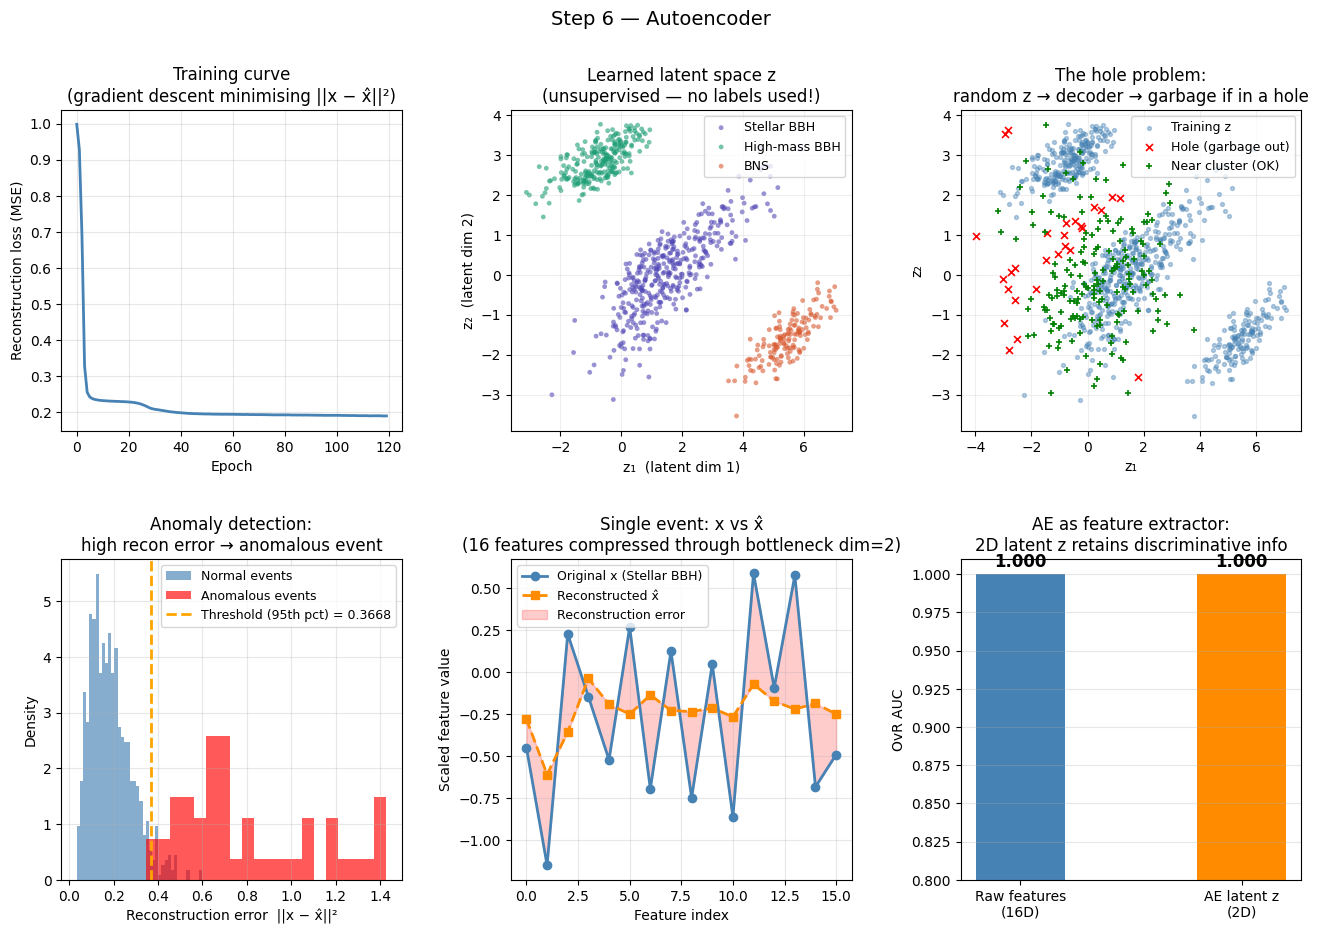

Plots saved.


In [10]:
# =============================================================================
# PART H — Full visualisation
# =============================================================================

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Step 6 — Autoencoder", fontsize=14)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)

colors = ["#534AB7", "#1D9E75", "#D85A30"]

# ── 1. Training loss ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(losses, color="steelblue", lw=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Reconstruction loss (MSE)")
ax1.set_title("Training curve\n(gradient descent minimising ||x − x̂||²)")
ax1.grid(alpha=0.3)

# ── 2. Latent space (coloured by population — AE found structure unsupervised)
ax2 = fig.add_subplot(gs[0, 1])
for k, (name, col) in enumerate(zip(pop_names, colors)):
    mask = labels == k
    ax2.scatter(Z_np[mask, 0], Z_np[mask, 1],
                c=col, s=12, alpha=0.6, label=name, edgecolors="none")
ax2.set_xlabel("z₁  (latent dim 1)"); ax2.set_ylabel("z₂  (latent dim 2)")
ax2.set_title("Learned latent space z\n(unsupervised — no labels used!)")
ax2.legend(fontsize=9); ax2.grid(alpha=0.2)

# ── 3. Latent space showing holes ────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(Z_np[:, 0], Z_np[:, 1], c="steelblue", s=8, alpha=0.4, label="Training z")
in_hole_mask  = in_holes
out_hole_mask = ~in_holes
ax3.scatter(z_random_np[in_hole_mask,  0], z_random_np[in_hole_mask,  1],
            c="red",   s=25, marker="x", lw=1.2, label="Hole (garbage out)", zorder=5)
ax3.scatter(z_random_np[out_hole_mask, 0], z_random_np[out_hole_mask, 1],
            c="green", s=25, marker="+", lw=1.2, label="Near cluster (OK)", zorder=5)
ax3.set_xlabel("z₁"); ax3.set_ylabel("z₂")
ax3.set_title("The hole problem:\nrandom z → decoder → garbage if in a hole")
ax3.legend(fontsize=9); ax3.grid(alpha=0.2)

# ── 4. Reconstruction error distribution ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(recon_errors, bins=40, density=True, alpha=0.65,
         color="steelblue", label="Normal events")
ax4.hist(anom_errors, bins=20, density=True, alpha=0.65,
         color="red", label="Anomalous events")
ax4.axvline(threshold, color="orange", lw=2, linestyle="--",
            label=f"Threshold (95th pct) = {threshold:.4f}")
ax4.set_xlabel("Reconstruction error  ||x − x̂||²")
ax4.set_ylabel("Density")
ax4.set_title("Anomaly detection:\nhigh recon error → anomalous event")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

# ── 5. Original vs reconstructed (one event) ────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
idx = 42
ax5.plot(X_scaled[idx], "o-", color="steelblue", lw=2, label=f"Original x ({pop_names[labels[idx]]})")
ax5.plot(X_rec_np[idx], "s--", color="darkorange", lw=2, label="Reconstructed x̂")
ax5.fill_between(range(D_INPUT),
                 X_scaled[idx], X_rec_np[idx],
                 alpha=0.2, color="red", label="Reconstruction error")
ax5.set_xlabel("Feature index"); ax5.set_ylabel("Scaled feature value")
ax5.set_title("Single event: x vs x̂\n(16 features compressed through bottleneck dim=2)")
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

# ── 6. AE as feature extractor for a downstream classifier ───────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr_raw = LogisticRegression(max_iter=500).fit(X_scaled, labels)
lr_lat = LogisticRegression(max_iter=500).fit(Z_np,     labels)

from sklearn.preprocessing import label_binarize
y_bin_raw = label_binarize(labels, classes=[0,1,2])
y_bin_lat = label_binarize(labels, classes=[0,1,2])

auc_raw = roc_auc_score(y_bin_raw, lr_raw.predict_proba(X_scaled),  multi_class="ovr")
auc_lat = roc_auc_score(y_bin_lat, lr_lat.predict_proba(Z_np),       multi_class="ovr")

ax6 = fig.add_subplot(gs[1, 2])
bars = ax6.bar(["Raw features\n(16D)", "AE latent z\n(2D)"],
               [auc_raw, auc_lat],
               color=["steelblue", "darkorange"], width=0.4)
for bar, v in zip(bars, [auc_raw, auc_lat]):
    ax6.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax6.set_ylim(0.8, 1.01); ax6.set_ylabel("OvR AUC")
ax6.set_title("AE as feature extractor:\n2D latent z retains discriminative info")
ax6.grid(alpha=0.3, axis="y")

plt.savefig("./step6_autoencoder.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Plots saved.")

In [11]:
# =============================================================================
# KEY TAKEAWAYS
# =============================================================================
print("\n" + "=" * 60)
print("  KEY TAKEAWAYS — STEP 6")
print("=" * 60)
print("""
1. AUTOENCODER = Encoder E(x)→z + Decoder D(z)→x̂
   Loss = MSE reconstruction: L = ||x − D(E(x))||²
   Same minimisation principle as every previous step.

2. The BOTTLENECK forces the network to learn the most
   important structure. Like PCA, but non-linear.

3. The LATENT SPACE z organises data semantically —
   similar events cluster together — with NO labels.

4. ANOMALY DETECTION for free: train on background, then
   flag events with high reconstruction error.

5. THE HOLE PROBLEM:
   The latent space is an unstructured scatter. There is no
   guarantee that z ~ N(0,I) produces meaningful outputs.
   Random sampling lands in holes → garbage from the decoder.

6. ROOT CAUSE: the AE only optimises L_recon. There is no
   constraint on WHAT the latent distribution looks like.

UP NEXT — STEP 7 (VAE):
   We add a regularisation term to the loss:
       L = L_recon  +  β · KL( q(z|x) || N(0,I) )
   The KL term penalises q(z|x) for deviating from N(0,I).
   This fills in the holes, making the space continuous and
   sample-able — turning the AE into a proper generative model.
   We'll derive the KL divergence from first principles.
""")


  KEY TAKEAWAYS — STEP 6

1. AUTOENCODER = Encoder E(x)→z + Decoder D(z)→x̂
   Loss = MSE reconstruction: L = ||x − D(E(x))||²
   Same minimisation principle as every previous step.

2. The BOTTLENECK forces the network to learn the most
   important structure. Like PCA, but non-linear.

3. The LATENT SPACE z organises data semantically —
   similar events cluster together — with NO labels.

4. ANOMALY DETECTION for free: train on background, then
   flag events with high reconstruction error.

5. THE HOLE PROBLEM:
   The latent space is an unstructured scatter. There is no
   guarantee that z ~ N(0,I) produces meaningful outputs.
   Random sampling lands in holes → garbage from the decoder.

6. ROOT CAUSE: the AE only optimises L_recon. There is no
   constraint on WHAT the latent distribution looks like.

UP NEXT — STEP 7 (VAE):
   We add a regularisation term to the loss:
       L = L_recon  +  β · KL( q(z|x) || N(0,I) )
   The KL term penalises q(z|x) for deviating from N(0,I).
  